# 2cm2 (full trajectory) — how many metastable states, POCKET features?

`build_spectral_gap.py`'s ligand-inclusive re-validation found k=4 (not the protein-only
run's k=3) -- two independently-trained overparametrized models (k=5,6) agreeing on a
spectral-gap elbow at process 4. The POCKET feature set (whole-protein side-chain COM-COM
+ all-atom 5A ligand-protein contacts, `data.build_features_pocket`) is a third,
separately-engineered feature set -- built later this session to fix H-atom
relaxation-lag artifacts the ligand-inclusive COM-only ligand term caused in chi-MEP work
-- that has been used throughout this session's actual pocket-model work assuming k=3,
without ever running this same check on it. This notebook does that: same
`amore.inverse_pcca` overparametrization/spectral-gap methodology, same lag=20 full
trajectory, bracketing k=3 on both sides (k=3,4,5,6).


In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import torch

SRC = os.path.abspath(os.path.join("..", "..", "src"))
LIB = os.path.abspath(os.path.join("..", "2cm2", "lib"))
sys.path.insert(0, SRC)
sys.path.insert(0, LIB)
import data, train, run, analysis as A
from amore.isokann import ChiNetMulti
from amore.inverse_pcca import (
    inverse_pcca, group_conjugate_pairs, find_spectral_gap, plot_complex_plane, rate_matrix,
)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TAU = 1.0   # arbitrary consistent unit; the gap is about ratios, not absolute time
plt.rcParams["figure.dpi"] = 120
print("device:", DEVICE)

device: cuda


## Full trajectory, lag=20, pocket features

Same dynamic NSTART/NEND/LAG repointing technique as the ligand-inclusive re-validation.
`pocket=True` (takes precedence over `include_ligand`) gives every cache path its own
`_pocket` tag, so this never touches or collides with either the protein-only or
ligand-inclusive full-trajectory caches under the same `$CM2_SCRATCH`.


In [2]:
data.NSTART = 0
data.NEND = 2979     # NEND + LAG must stay < 3000 (the trajectory's frame count)
data.LAG = 20
KVALS = [3, 4, 5, 6]   # brackets k=3 (this session's working assumption) both sides,
                       # same narrower re-validation sweep as the ligand-inclusive check
print(f"anchors: [{data.NSTART}, {data.NEND})  lag={data.LAG}  pocket=True  "
      f"-> {data.NEND - data.NSTART} anchors")

feats = data.build_features_pocket(use_pbc=True, verbose=True)
D0n, Dtn, mu, sd = train.normalise(feats["D0"], feats["Dt"])
D0n = D0n.to(DEVICE); Dtn = Dtn.to(DEVICE)
N, F = D0n.shape; Kb = Dtn.shape[1]
print(f"N anchors={N}  F features={F} ({len(feats['res_pairs'])} sidechain-COM-COM + "
      f"{feats['n_contact']} ligand-protein all-atom contact)  Kb(lag replicas)={Kb}")

anchors: [0, 2979)  lag=20  pocket=True  -> 2979 anchors
[features_pocket] loading cache /scratch/htc/jkresse/2cm2/features_pocket_0_2979_lag20_pbc_rcut25.pt


N anchors=2979  F features=23212 (16871 sidechain-COM-COM + 6341 ligand-protein all-atom contact)  Kb(lag replicas)=1


In [3]:
def load_net(k, F=F):
    # run.get_model trains fresh (cached to scratch) if this (k, NSTART, NEND, LAG,
    # pocket) combination hasn't been trained before.
    m = run.get_model(k, pocket=True, verbose=True)
    net = ChiNetMulti(F, k, hidden=m["hidden"]).to(DEVICE)
    net.load_state_dict(m["net_state"]); net.eval()
    return net, m

def eval_chi(net, D0n=D0n):
    with torch.no_grad():
        return net(D0n).cpu().numpy()

def make_propagate(net, Dtn=Dtn, N=N, F=F, Kb=Kb):
    def propagate():
        with torch.no_grad():
            flat = Dtn.reshape(N * Kb, F)
            return net(flat).reshape(N, Kb, -1).mean(1).cpu().numpy()
    return propagate

results = {}
for k in KVALS:
    print(f"=== training/loading k={k} (full trajectory, lag={data.LAG}, pocket) ===")
    net, m = load_net(k)
    chi = eval_chi(net)
    keff = int((chi.std(0) > 0.05).sum())
    print(f"  chi std/output: {chi.std(0).round(3)}  k_eff={keff}")
    if keff < 2:
        print(f"  collapsed (k_eff={keff}), skipping inverse_pcca for this k")
        results[k] = dict(m=m, net=net, chi=chi, result=None)
        continue
    try:
        result = inverse_pcca(chi, make_propagate(net), TAU, reversible=True)
        rev = True
    except ValueError as e:
        print(f"  reversible=True failed ({e})\n  -> falling back to reversible=False")
        result = inverse_pcca(chi, make_propagate(net), TAU, reversible=False)
        rev = False
    processes = group_conjugate_pairs(result.lam)
    gap = find_spectral_gap(processes) if len(processes) >= 2 else None
    results[k] = dict(m=m, net=net, chi=chi, result=result, reversible=rev,
                      processes=processes, gap=gap)
    print(f"  reversible={rev}  residual(RMS/entry)={result.residual/np.sqrt(chi.size):.4f}")
    print(f"  distinct processes ({len(processes)}):")
    for p in processes:
        print(f"    |lambda|={p.modulus:.4f}  {p.kind}  lam={p.lam:.4f}")
    if gap is not None:
        print(f"  find_spectral_gap: k={gap.k} processes above it "
              f"({gap.modulus_above:.4f} -> {gap.modulus_below:.4f}, drop={gap.gap:.4f})")
    print()

=== training/loading k=3 (full trajectory, lag=20, pocket) ===
[model] loading cache /scratch/htc/jkresse/2cm2/model_k3_pocket_0_2979_lag20_pbc.pt


  chi std/output: [0.439 0.408 0.093]  k_eff=3
  reversible=True  residual(RMS/entry)=0.0245
  distinct processes (3):
    |lambda|=1.0000  real  lam=1.0000+0.0000j
    |lambda|=0.9915  real  lam=0.9915+0.0000j
    |lambda|=0.7450  real  lam=0.7450+0.0000j
  find_spectral_gap: k=2 processes above it (0.9915 -> 0.7450, drop=0.2465)

=== training/loading k=4 (full trajectory, lag=20, pocket) ===
[features_pocket] loading cache /scratch/htc/jkresse/2cm2/features_pocket_0_2979_lag20_pbc_rcut25.pt


[k=4] iter 1/200  train 5.3561e-02  val 7.2983e-01  k_eff 4  (2s)


[k=4] iter 11/200  train 1.8877e-03  val 4.2576e-01  k_eff 4  (17s)


[k=4] iter 21/200  train 1.4930e-03  val 4.5384e-01  k_eff 4  (32s)


...

[k=6] iter 191/200  train 3.1679e-03  val 5.3372e-01  k_eff 6  (342s)


[k=6] iter 200/200  train 1.4321e-03  val 5.2350e-01  k_eff 6  (366s)


[model] cached -> /scratch/htc/jkresse/2cm2/model_k6_pocket_0_2979_lag20_pbc.pt


  chi std/output: [0.284 0.205 0.446 0.07  0.18  0.419]  k_eff=6
  reversible=True failed (inverse_pcca(reversible=True): Lambda_S has a non-negligible imaginary eigenvalue component (max |Im| = 2.426e-02) -- this looks non-reversible; call with reversible=False.)
  -> falling back to reversible=False


  reversible=False  residual(RMS/entry)=0.0426
  distinct processes (5):
    |lambda|=1.0000  real  lam=1.0000+0.0000j
    |lambda|=0.9823  real  lam=0.9823+0.0000j
    |lambda|=0.9598  real  lam=0.9598+0.0000j
    |lambda|=0.9536  complex_pair  lam=0.9533+0.0243j
    |lambda|=0.5117  real  lam=0.5117+0.0000j
  find_spectral_gap: k=4 processes above it (0.9536 -> 0.5117, drop=0.4420)



## Loss curves

`train` (MSE to the ISA regression target) and `val` (held-out Gram-Schmidt residual) per
outer ISA power iteration.


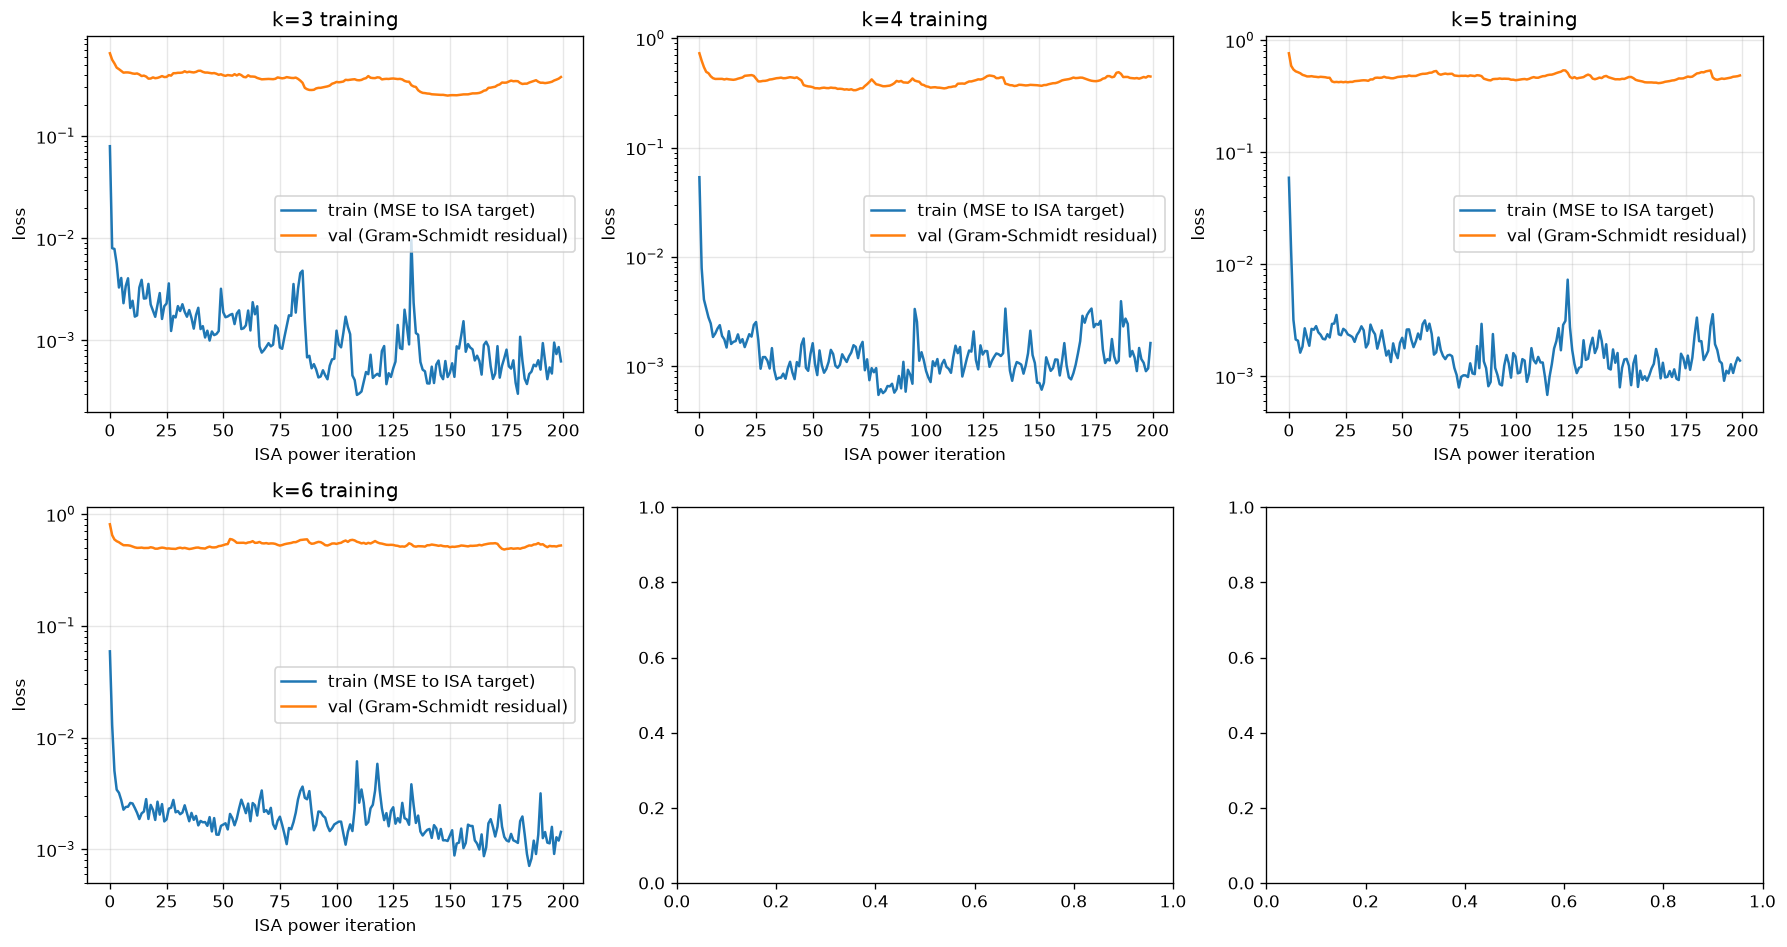

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, k in zip(axes.ravel(), KVALS):
    A.plot_loss(results[k]["m"], ax=ax)
fig.tight_layout(); plt.savefig("loss_curves.png", dpi=150, bbox_inches="tight"); plt.show()

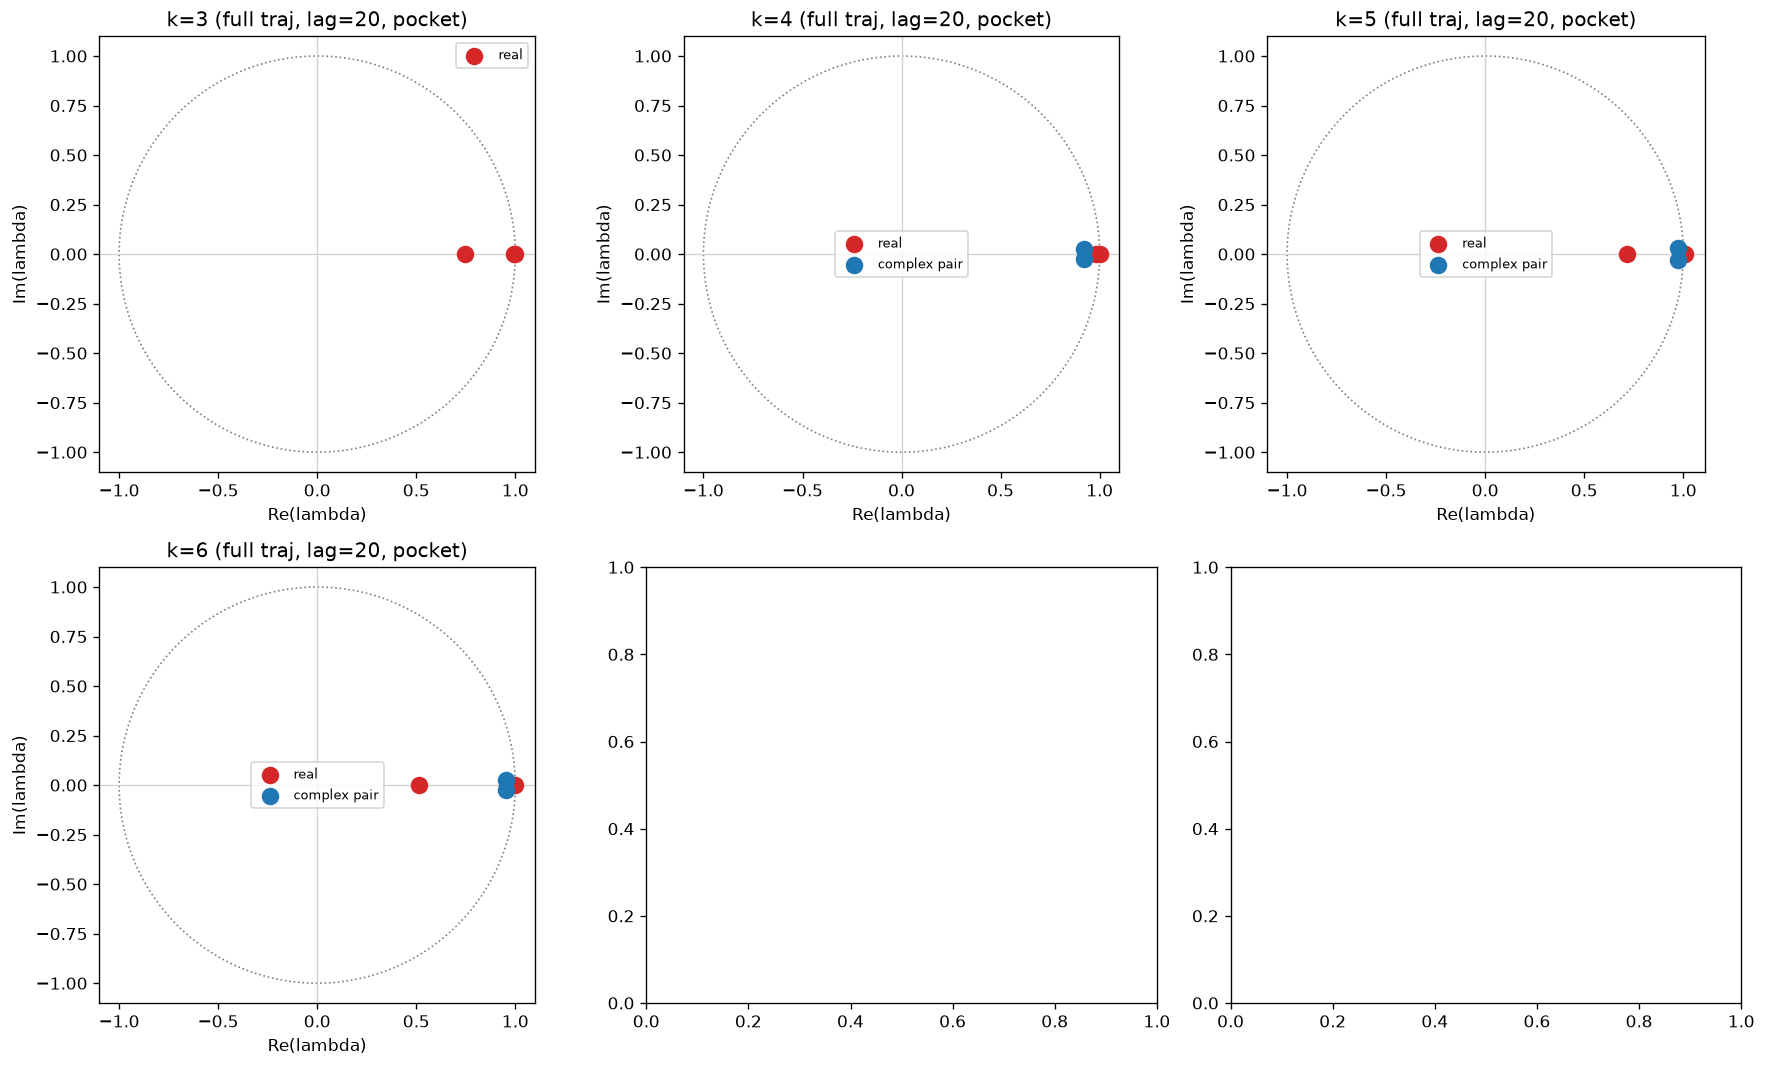

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, k in zip(axes.ravel(), KVALS):
    if results[k]["result"] is None:
        ax.set_title(f"k={k} (collapsed)")
        continue
    plot_complex_plane(ax, results[k]["result"].lam)
    ax.set_title(f"k={k} (full traj, lag={data.LAG}, pocket)")
fig.tight_layout(); plt.savefig("spectral_gap_complex_plane.png", dpi=150, bbox_inches="tight"); plt.show()

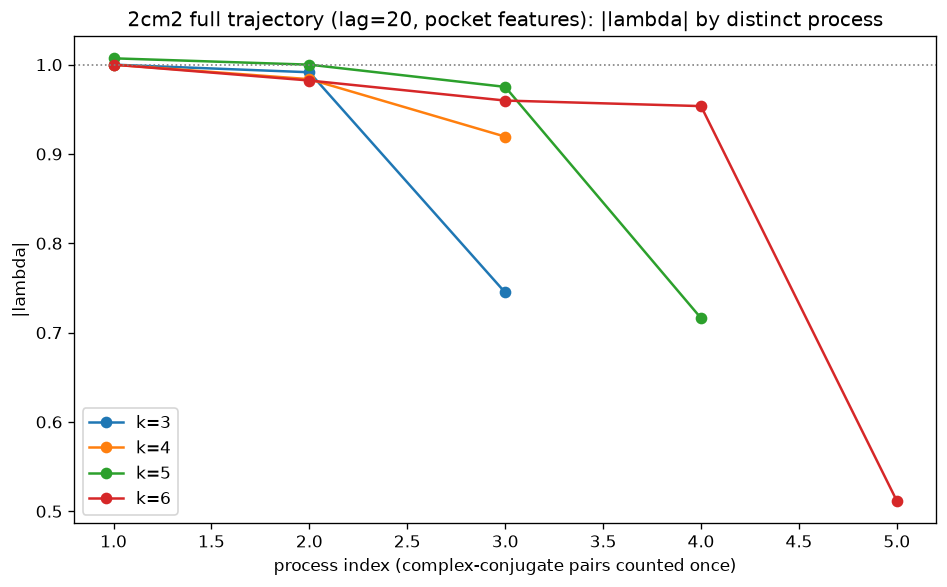

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
for k in KVALS:
    if results[k]["result"] is None:
        continue
    moduli = [p.modulus for p in results[k]["processes"]]
    ax.plot(np.arange(1, len(moduli) + 1), moduli, "o-", label=f"k={k}")
ax.axhline(1.0, color="gray", lw=1, ls=":")
ax.set_xlabel("process index (complex-conjugate pairs counted once)")
ax.set_ylabel("|lambda|")
ax.set_title(f"2cm2 full trajectory (lag={data.LAG}, pocket features): |lambda| by distinct process")
ax.legend()
fig.tight_layout(); plt.savefig("spectral_gap_lambda.png", dpi=150, bbox_inches="tight"); plt.show()